<img style="float: right; width:140px;" src="EarthCODE_key-visual.jpg">

# Access [Title of Dataset] product from ESA Open Science Catalogue 



This notebook provides a minimal, reusable example on how to load, open and read `[Dataset Title]` stored in the Open Science Catalogue using Python.<br>
<br>
The goal of this notebook is to provide an straightforward and consistent starting point for any users to open the product they are interested in. <br>
The notebook can also be easily adabted to any dataset in the catalogue. 

The `[Title of the Project]` provides `[number of products]` that can be accessed from Open Science Catalogue. <br>

`INSERT HERE AN URL TO OPEN SCIENCE CATALOGUE PRODUCT PAGE AS A REFERENCE`<br>

Please find below their short description. 


1. **Dataset 1**: short description
2. **Dataset 2**: short description
3. **Dataset 3**: short description<br>

It is a good practice to provide some **context to the datasets: including file naming conventions and the differences between various products**.<br> 
As an example if you have one or more datasets under one collection, please specify how the correct product should be selected. 


*Provide information about the format of the datasets, their temporal and spatial coverage and the link to Open Science Catalogue collection.json for more details and documentation.*<br>


**Contents of the notebook:**
1. Required dependencies and storage configuration setup
2. Locating a dataset from object storage
3. Opening a `.zarr` store with `xarray`*
5. Inspecting metadata and structure
6. Reading and subsetting data
7. Basic visualization
8. Additional notes

`* *If your dataset is in different format: e.g. .parquet or .cog you may require different setup and confuguration steps to access the product. Please adapt the notebook then accordingly. See the example of .parquet data access exposed on Open Science Catalogue.: [https://github.com/ESA-EarthCODE/data_access_examples/blob/main/lightning2earthcare/data_access.ipynb](https://github.com/ESA-EarthCODE/data_access_examples/blob/main/lightning2earthcare/data_access.ipynb)*

## 1. Required dependencies and storage configuration setup

Required packages:
- `xarray`
- `zarr`
- `s3fs` or `fsspec` (for remote/object-storage access)
- `pystac-client` (optional, for catalogue search)
- `matplotlib` (for plotting)
- `geopandas` (optional)
- `pandas` (optional)
- `duckdb` (optional)

In [8]:
# !pip install xarray zarr s3fs fsspec pystac-client matplotlib
import xarray as xr
import fsspec
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
#import duckdb

### Storage configuration setup 

In [9]:
# setup bucket access
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
prefix = 'OSCAssets/storm-data/'   # Please remember to change the PREFIX if you would like to open different product (the last part of the path to the product 'storm-data')

## 2. Locating a dataset from the object storage

The ESA Open Science Catalogue exposes datasets via STAC Collections. 
If you woulld like to open product stored in .zarr format, you can find the link to the product by expanding: <br>**`"Asset" section --> 'Copy URL"`** . <br>

See as example [ARCEME Data Cube](https://opensciencedata.esa.int/products/arceme-datacubes-global/arceme-datacubes-global-10051-dhp)


In [10]:
# Option A: Copy and paste the URL link to the object sotrage where the data cube is stored and save it under 'url' variable
url_zarr = 'https://s3.waw4-1.cloudferro.com/swift/v1/ARCEME-DC-DHP-GLOBAL/DC__101342_d__2022-11-12__2024-11-12.zarr'

In [ ]:
# Option B: Open via fsspec mapper (useful for S3 / object storage with anonymous or credentialed access)
fs = fsspec.filesystem("s3", anon=True)  # set anon=False and provide credentials if required
mapper = fs.get_mapper(url_zarr)

## 3. Open the `.zarr` file with `xarray`

`.zarr` stores can be opened directly from local disk, S3-compatible object storage, or HTTP(S) endpoints using `xarray.open_zarr`, combined with `fsspec` mappers for remote access.

In [11]:
ds = xr.open_zarr(url_zarr)
ds

<xarray.Dataset> Size: 10GB
Dimensions:                       (time_sentinel_2_l2a: 144, y: 1000, x: 1000,
                                   time_cop_dem_glo_30_dged_cog: 1,
                                   time_esa_worldcover: 1,
                                   time_sentinel_1_rtc: 116)
Coordinates:
    orbit_state                   (time_sentinel_1_rtc) <U10 5kB dask.array<chunksize=(25,), meta=np.ndarray>
  * time_cop_dem_glo_30_dged_cog  (time_cop_dem_glo_30_dged_cog) datetime64[ns] 8B ...
  * time_esa_worldcover           (time_esa_worldcover) datetime64[ns] 8B 202...
  * time_sentinel_1_rtc           (time_sentinel_1_rtc) datetime64[ns] 928B 2...
  * time_sentinel_2_l2a           (time_sentinel_2_l2a) datetime64[ns] 1kB 20...
  * x                             (x) float64 8kB 4.567e+05 ... 4.667e+05
  * y                             (y) float64 8kB 6.597e+06 ... 6.588e+06
Data variables: (12/18)
    B01                           (time_sentinel_2_l2a, y, x) float32 576MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    B02                           (time_sentinel_2_l2a, y, x) float32 576MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    B03                           (time_sentinel_2_l2a, y, x) float32 576MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    B04                           (time_sentinel_2_l2a, y, x) float32 576MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    B05                           (time_sentinel_2_l2a, y, x) float32 576MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    B06                           (time_sentinel_2_l2a, y, x) float32 576MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    ...                            ...
    COP_DEM                       (time_cop_dem_glo_30_dged_cog, y, x) float64 8MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
    ESA_LC                        (time_esa_worldcover, y, x) float32 4MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
    SCL                           (time_sentinel_2_l2a, y, x) float32 576MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    cloud_mask                    (time_sentinel_2_l2a, y, x) float32 576MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    vh                            (time_sentinel_1_rtc, y, x) float64 928MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
    vv                            (time_sentinel_1_rtc, y, x) float64 928MB dask.array<chunksize=(25, 500, 500), meta=np.ndarray>
Attributes: (12/41)
    Sentinel_2_SCL_description:  0: no_data, 1: saturated_or_defective, 2: da...
    central_x:                   461730.0
    central_y:                   6592490.0
    cloud_mask_algorithm:        SEnSeIv2/SegFormerB2
    cloud_mask_citation:         https://www.doi.org/10.1109/TGRS.2024.3391625
    cloud_mask_description:      0: Unoccluded, 1: Thick cloud, 2: Thin cloud...
    ...                          ...
    temporal_window:             event_date -12 months to +12 months
    tile_edge_size_meters:       10000
    tile_size_px:                1000x1000
    time_axis:                   time_sentinel_2_l2a, time_sentinel_1_rtc, ti...
    time_coverage_end:           2024-11-12
    time_coverage_start:         2022-11-12

## 4. Inspecting metadata and structure

Once opened, the dataset behaves like a standard `xarray.Dataset`. You can inspect dimensions, coordinates, variables, and attributes (CF metadata, units, etc.).

In [13]:
print("Dimensions:", ds.dims)
print("Coordinates:", list(ds.coords))
print("Data variables:", list(ds.data_vars))
print("Global attributes:")
for k, v in ds.attrs.items():
    print(f"  {k}: {v}")

Dimensions: FrozenMappingWarningOnValuesAccess({'time_sentinel_2_l2a': 144, 'y': 1000, 'x': 1000, 'time_cop_dem_glo_30_dged_cog': 1, 'time_esa_worldcover': 1, 'time_sentinel_1_rtc': 116})
Coordinates: ['orbit_state', 'time_cop_dem_glo_30_dged_cog', 'time_esa_worldcover', 'time_sentinel_1_rtc', 'time_sentinel_2_l2a', 'x', 'y']
Data variables: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'COP_DEM', 'ESA_LC', 'SCL', 'cloud_mask', 'vh', 'vv']
Global attributes:
  Sentinel_2_SCL_description: 0: no_data, 1: saturated_or_defective, 2: dark_area_pixels, 3: cloud_shadows, 4: vegetation, 5: not_vegetated, 6: water, 7: unclassified, 8: cloud_medium_probability, 9: cloud_high_probability, 10: thin_cirrus, 11: snow
  central_x: 461730.0
  central_y: 6592490.0
  cloud_mask_algorithm: SEnSeIv2/SegFormerB2
  cloud_mask_citation: https://www.doi.org/10.1109/TGRS.2024.3391625
  cloud_mask_description: 0: Unoccluded, 1: Thick cloud, 2: Thin cloud, 3: Shadow
  cloud

## 5. Reading and subsetting data

Zarr's chunked storage allows lazy loading - data is only read into memory when explicitly requested or computed. This is efficient for large datasets.

In [24]:
# Select a variable (replace 'variable_name' with an actual variable from ds.data_vars)
var_name = list(ds.data_vars)[13]
da = ds[var_name]

In [25]:
# Subset by index or coordinate values
subset = da.isel(time=0) if "time" in da.dims else da

# Load into memory (triggers actual data read)
subset_loaded = subset.compute()
subset_loaded

<xarray.DataArray 'ESA_LC' (time_esa_worldcover: 1, y: 1000, x: 1000)> Size: 4MB
array([[[40., 40., 40., ..., 40., 40., 40.],
        [40., 40., 40., ..., 40., 40., 40.],
        [40., 40., 40., ..., 40., 40., 40.],
        ...,
        [40., 40., 40., ..., 40., 40., 40.],
        [40., 40., 40., ..., 40., 40., 40.],
        [40., 40., 40., ..., 40., 40., 40.]]],
      shape=(1, 1000, 1000), dtype=float32)
Coordinates:
  * time_esa_worldcover  (time_esa_worldcover) datetime64[ns] 8B 2020-01-01
  * x                    (x) float64 8kB 4.567e+05 4.567e+05 ... 4.667e+05
  * y                    (y) float64 8kB 6.597e+06 6.597e+06 ... 6.588e+06

## 6. Basic visualization of selected variable

This code snippet provides a basic visualisation of one selected variable. User are free to expand this section or to provide a separate notebook on visualisation of their products to ensure that they are properly interpreted by the users. <br>

Please see example of visualisation notebook stored on EarthCODE repository. Such notebook can also accompany the product published to open science catalogue to facilitate the usahge of the datasets. [https://github.com/ESA-EarthCODE/data_access_examples/blob/main/lightning2earthcare/data_visualization.ipynb](https://github.com/ESA-EarthCODE/data_access_examples/blob/main/lightning2earthcare/data_visualization.ipynb)

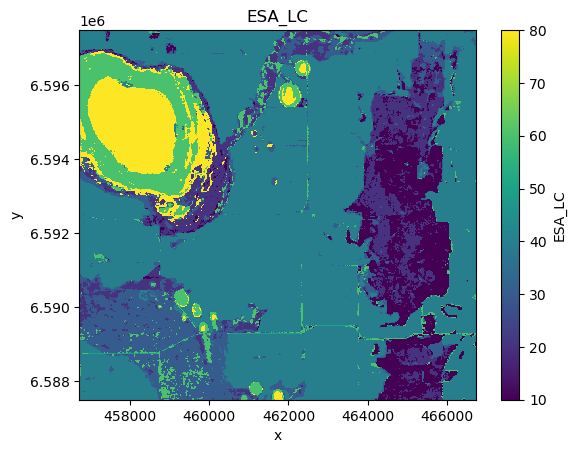

In [26]:
subset_loaded.plot()
plt.title(var_name)
plt.show()

## 7. Additional notes 
This notebook proivde avery simple for data exploitation and simple visualisation of the variable of interest. 
Please adapt the notebook accordingly, also depending on how much details are needed to undertsand your file structure, variables and values of the product.<br>

**See examples on the data access** in the GitHub Repository: [https://github.com/ESA-EarthCODE/data_access_examples/tree/main](https://github.com/ESA-EarthCODE/data_access_examples/tree/main ) <br>

- Open Science catalogue serves datasets that are hosted on **public, openly-accessible** object storage;
- In some specific cases the authenthication might be required. If this is your case **please provide information on a way to obtain the credentials** (e.g., S3 access keys, OAuth tokens ir other.)
- For very large datasets, consider using `dask` (xarray uses it automatically with `open_zarr`) to parallelize and chunk computations. 
---

**Next steps:** 
- See the accompanying `README.md` for context and where it should be published.
- If you have any questions, please write them in [EarthCODE discourse forum](https://discourse-earthcode.eox.at/c/data-workflows/10), or send us an [email](mailto:earthcode@esa.int)